# Face Recognition using CNN

This project uses a Convolutional Neural Network (CNN) to recognize different human faces using the Olivetti Faces dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
faces = fetch_olivetti_faces(shuffle=True, random_state=42)

X = faces.images
y = faces.target

print("Images :", X.shape)
print("Labels :", y.shape)
print("Total Classes :", len(np.unique(y)))

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Images : (400, 64, 64)
Labels : (400,)
Total Classes : 40


In [3]:
X = X.reshape(-1,64,64,1)

y = to_categorical(y)

print("Image Shape :",X.shape)
print("Label Shape :",y.shape)

Image Shape : (400, 64, 64, 1)
Label Shape : (400, 40)


In [4]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Images :",X_train.shape[0])
print("Testing Images :",X_test.shape[0])

Training Images : 320
Testing Images : 80


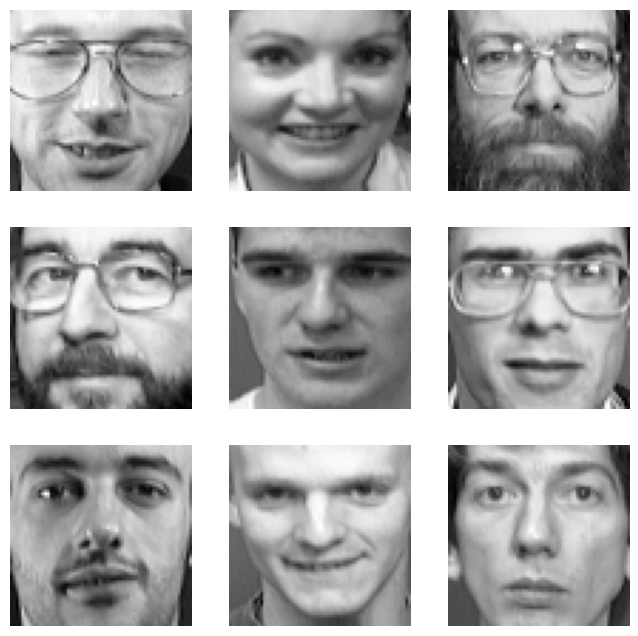

In [5]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i].reshape(64,64),cmap="gray")
    plt.axis("off")

plt.show()

In [6]:
model=Sequential()

model.add(Conv2D(16,(3,3),activation="relu",input_shape=(64,64,1)))
model.add(MaxPooling2D())

model.add(Conv2D(32,(3,3),activation="relu"))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(128,activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(40,activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │         5,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 812,904 (3.10 MB)

 Trainable params: 812,904 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stop=EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [9]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=16,
    callbacks=[early_stop]
)

Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.0188 - loss: 3.7366 - val_accuracy: 0.0375 - val_loss: 3.6832
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.0406 - loss: 3.6835 - val_accuracy: 0.0750 - val_loss: 3.6753
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.0406 - loss: 3.6694 - val_accuracy: 0.0750 - val_loss: 3.6582
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.0562 - loss: 3.6404 - val_accuracy: 0.1125 - val_loss: 3.6267
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.1156 - loss: 3.6146 - val_accuracy: 0.1750 - val_loss: 3.5717
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.1156 - loss: 3.5229 - val_accuracy: 0.3125 - val_loss: 3.4869
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.1656 - loss: 3.3704 - val_accuracy: 0.4375 - val_loss: 3.1711
Epoch 8/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.2313 - loss: 3.0436 - val_accuracy: 0.5500 - v

In [10]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy :", round(accuracy*100,2), "%")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8625 - loss: 0.6408 
Test Accuracy : 86.25 %


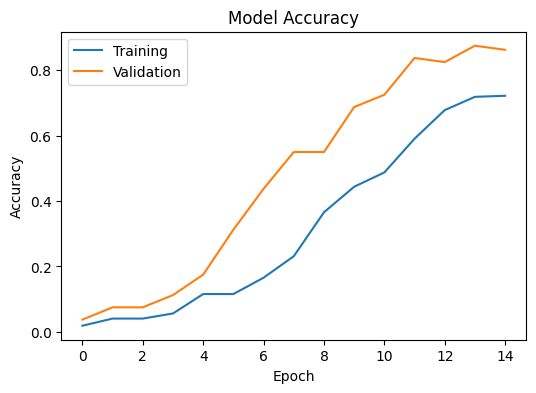

In [11]:
plt.figure(figsize=(6,4))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training","Validation"])

plt.show()

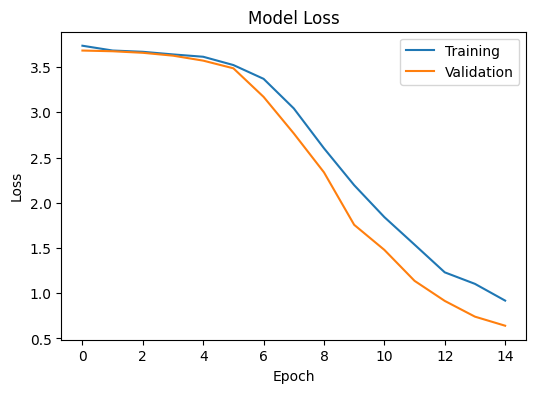

In [12]:
plt.figure(figsize=(6,4))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training","Validation"])

plt.show()

Actual Person : 14
Predicted Person : 14


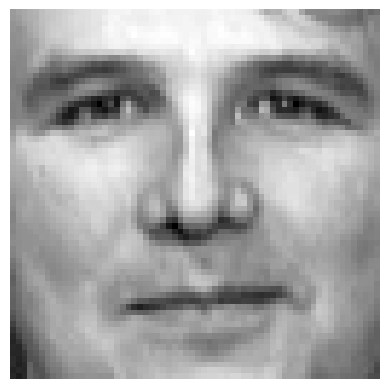

In [14]:
index = np.random.randint(len(X_test))

prediction = model.predict(
    X_test[index].reshape(1,64,64,1),
    verbose=0
)

predicted = np.argmax(prediction)
actual = np.argmax(y_test[index])

plt.imshow(X_test[index].reshape(64,64), cmap="gray")
plt.axis("off")

print("Actual Person :", actual)
print("Predicted Person :", predicted)

In [15]:
model.save("Face_Recognition_CNN.keras")

print("Model saved successfully.")

Model saved successfully.


## Conclusion

A Convolutional Neural Network (CNN) was developed to recognize faces using the Olivetti Faces dataset. The model extracted facial features from grayscale images and classified them into different identities. The obtained accuracy demonstrates that CNNs are effective for face recognition tasks.